In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load the data
X = pd.read_csv('Comb_ligands_31conditions_X_codon_202604.csv', header=None)
y = pd.read_csv('Comb_ligands_31conditions_y_codon_202604.csv', header=None)

print("X shape:", X.shape)
print("y shape:", y.shape)

mask = y.iloc[:, 0].isin([0, 1, 2, 3, 4])

X = X.loc[mask, :]
y = y.loc[mask, :]

print(X.shape)
print(y.shape)


X shape: (30990, 6)
y shape: (30990, 1)
(5000, 6)
(5000, 1)


In [5]:
# Define the label mapping
label_mapping = {
    0: 'TNF', 1: 'LPS', 2: 'CpG', 3: 'PolyIC', 4: 'Pam3CSK'
}

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1, stratify = y)

# Define and train the model
model = RandomForestClassifier(random_state=1)
model.fit(X_train, y_train.values.ravel())

# Make predictions on the test set
y_pred = model.predict(X_test)

# Create confusion matrix using only test set predictions
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"Sum of confusion matrix: {np.sum(cm)}") # Verify the size of the confusion matrix

unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Condition {label}: {count} samples")

print(f"Total: {sum(counts)} (should be 30,990)")

# Calculate accuracy
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.3f}")

# Sensitivity Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FN = np.sum(cm, axis=1) - TP  # False Negatives

# Compute sensitivity for the full confusion matrix
recall = cm / np.sum(cm, axis=1, keepdims=True)  # Normalize by row sums
recall = np.nan_to_num(recall)  # Replace NaN with 0 (for rows with zero actual instances)
print(recall)
print(np.sum(recall, axis=1))

# Precision Calculation (using the test set confusion matrix)
TP = np.diag(cm)  # True Positives
FP = np.sum(cm, axis=0) - TP  # False Positives

# Compute precision for the full confusion matrix
precision = cm / np.sum(cm, axis=0, keepdims=True)  # Normalize by column sums
precision = np.nan_to_num(precision)  # Replace NaN with 0 (for columns with zero predictions)
print(precision)
print(np.sum(precision, axis=0))

# Compute f-1 score for the full confusion matrix
# Ensure denominator is never zero by adding a small epsilon
epsilon = 1e-10  # A tiny constant to avoid division by zero
f1_score = np.where(
    (precision + recall) == 0,
    0,  # Assign 0 when both precision and recall are zero
    2 * (precision * recall) / (precision + recall + epsilon)  # Avoid exact zero division
)
print(f1_score)
print(np.sum(f1_score, axis=0))

[[320   2   0   0   8]
 [  8 242  36  10  34]
 [  4  45 223  33  25]
 [  2   7  15 302   4]
 [ 19  37  40  10 224]]
Sum of confusion matrix: 1650
Condition 0: 1000 samples
Condition 1: 1000 samples
Condition 2: 1000 samples
Condition 3: 1000 samples
Condition 4: 1000 samples
Total: 5000 (should be 30,990)
Model Accuracy: 0.795
[[0.96969697 0.00606061 0.         0.         0.02424242]
 [0.02424242 0.73333333 0.10909091 0.03030303 0.1030303 ]
 [0.01212121 0.13636364 0.67575758 0.1        0.07575758]
 [0.00606061 0.02121212 0.04545455 0.91515152 0.01212121]
 [0.05757576 0.11212121 0.12121212 0.03030303 0.67878788]]
[1. 1. 1. 1. 1.]
[[0.90651558 0.00600601 0.         0.         0.02711864]
 [0.02266289 0.72672673 0.11464968 0.02816901 0.11525424]
 [0.01133144 0.13513514 0.71019108 0.09295775 0.08474576]
 [0.00566572 0.02102102 0.0477707  0.85070423 0.01355932]
 [0.05382436 0.11111111 0.12738854 0.02816901 0.75932203]]
[1. 1. 1. 1. 1.]
[[0.93704246 0.00603318 0.         0.         0.0256   

In [6]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)

numpy: 1.26.4
pandas: 2.2.3
matplotlib: 3.9.2
seaborn: 0.13.2
scikit-learn: 1.5.2


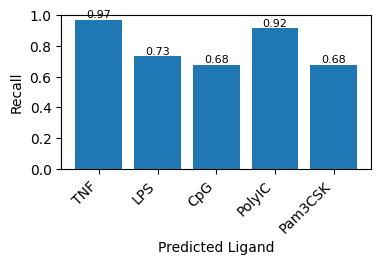

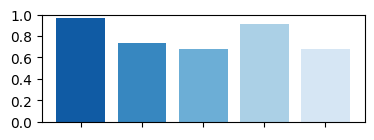

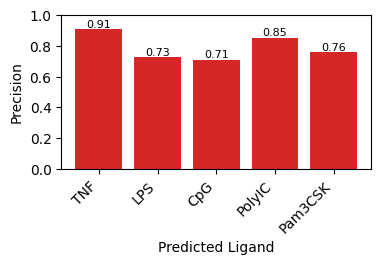

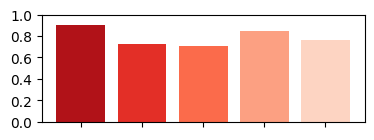

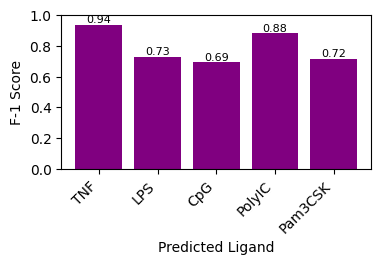

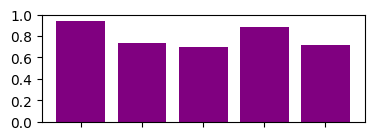

In [16]:
# Extract only the diagonal values
precision_diag = np.diag(precision)  # True positive precision values
recall_diag = np.diag(recall)  # True positive recall values
f1_score_diag = 2 * (precision_diag * recall_diag) / (precision_diag + recall_diag)

  # True positive f1 score values
f1_score_diagonal = np.full_like(f1_score, np.nan)  # Create NaN matrix for visualization
np.fill_diagonal(f1_score_diagonal, f1_score_diag)  # Fill diagonal with F1-scores

# Set to 1 to automatically download PNGs, 0 to not download
auto_download = 0
def save_and_download(filename, download=False, formats=None):
    """Saves the current figure in specified formats and optionally downloads it."""
    if formats is None:
        formats = ['pdf']  # Default format if none specified

    for fmt in formats:
        plt.savefig(f"{filename}.{fmt}", bbox_inches='tight', dpi=300)
        if download and auto_download:
            try:
                from google.colab import files
                files.download(f"{filename}.{fmt}")
            except ImportError:
                print("Not running in Colab environment.  Download skipped.")

# Recall Bar Plot
def plot_recall(with_labels=True):
    if with_labels:
        plt.figure(figsize=(4, 2))
        num_classes = len(recall_diag)
        colors = "tab:blue" # sns.color_palette("Blues_r", n_colors=num_classes)

        bars = plt.bar(range(num_classes), recall_diag, color=colors)

        #plt.title("True Positive Predictions for 31 Ligand Combinations using Sensitivity")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Recall")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        #save_and_download("31conditions_recall_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(recall_diag)), recall_diag, color=sns.color_palette("Blues_r", n_colors=len(recall_diag)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(recall_diag)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        #save_and_download("31conditions_recall_bar_plot_without_labels", download=True, formats=['pdf', 'png', 'eps', 'svg'])

    plt.show()

# Precision Bar Plot
def plot_precision(with_labels=True):
    if with_labels:
        plt.figure(figsize=(4, 2))
        num_classes = len(precision_diag)
        colors = "tab:red" #sns.color_palette("Reds_r", n_colors=num_classes)

        bars = plt.bar(range(num_classes), precision_diag, color=colors)

        #plt.title("True Positive Predictions for 31 Ligand Combinations using Precision")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("Precision")
        plt.ylim(0, 1)
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
        #save_and_download("31conditions_precision_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.figure(figsize=(300/72, 100/72))  # 300x100 pts
        plt.bar(range(len(precision_diag)), precision_diag, color=sns.color_palette("Reds_r", n_colors=len(precision_diag)))
        plt.ylim(0, 1)
        plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xticks(range(len(precision_diag)))  # Set tick locations
        plt.gca().set_xticklabels([])  # Remove tick labels
        #save_and_download("31conditions_precision_bar_plot_without_labels", download=True, formats=['pdf','png', 'eps', 'svg'])

    plt.show()

# f1_score_diag Bar plot
def plot_f1_score_diag(with_labels=True):
    plt.figure(figsize=(4, 2) if with_labels else (300/72, 100/72))  # Set figure size

    num_classes = len(f1_score_diag)  # Use f1_score_diag for diagonal elements
    colors = "purple" #sns.color_palette("Purples_r", n_colors=num_classes)

    bars = plt.bar(range(num_classes), f1_score_diag, color=colors)

    plt.ylim(0, 1)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])

    if with_labels:
        #plt.title("True Positive Predictions for 31 Ligand Combinations using F-1 Score")
        plt.xlabel("Predicted Ligand")
        plt.ylabel("F-1 Score")
        plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')

        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
                     ha='center', va='bottom', fontsize=8)

        # Save labeled plot once (moved outside the loop)
        save_and_download("5conditions_f1score_bar_plot_with_labels", download=True, formats=['pdf'])
    else:
        plt.xticks(range(num_classes))  # Set tick locations
        plt.gca().set_xticklabels([])  # Hide x-axis labels

        # Save unlabeled plot in multiple formats
        save_and_download("5conditions_f1score_bar_plot_without_labels", download=True, formats=['pdf', 'png', 'eps', 'svg'])

    plt.show()



# Generate all versions of the plots
plot_recall(with_labels=True)
plot_recall(with_labels=False)
plot_precision(with_labels=True)
plot_precision(with_labels=False)
plot_f1_score_diag(with_labels=True)
plot_f1_score_diag(with_labels=False)

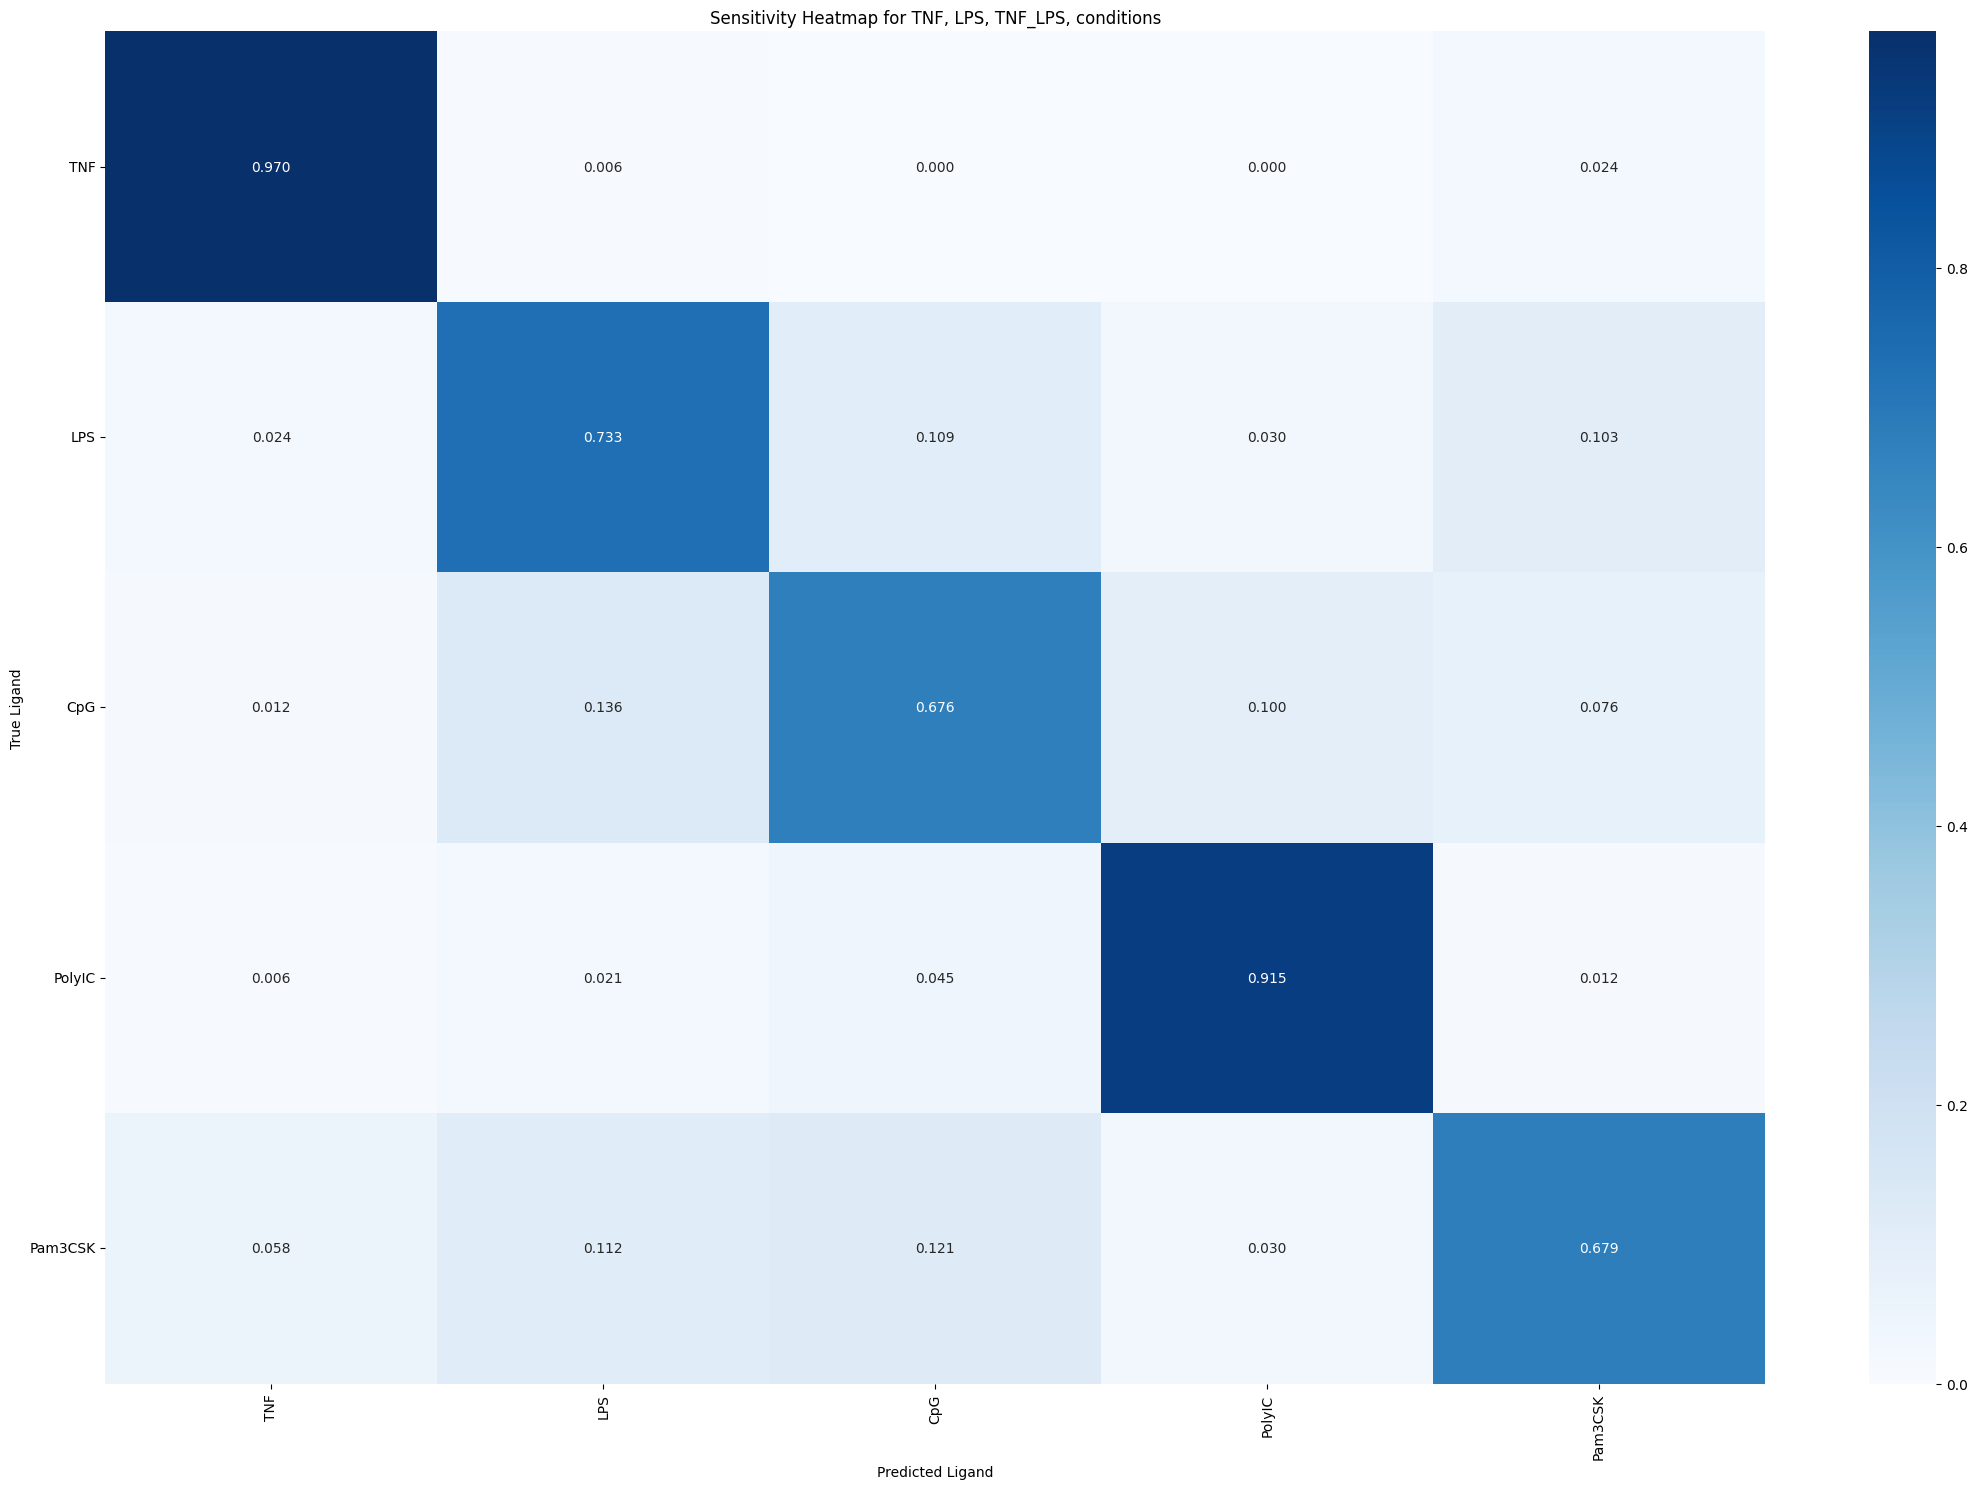

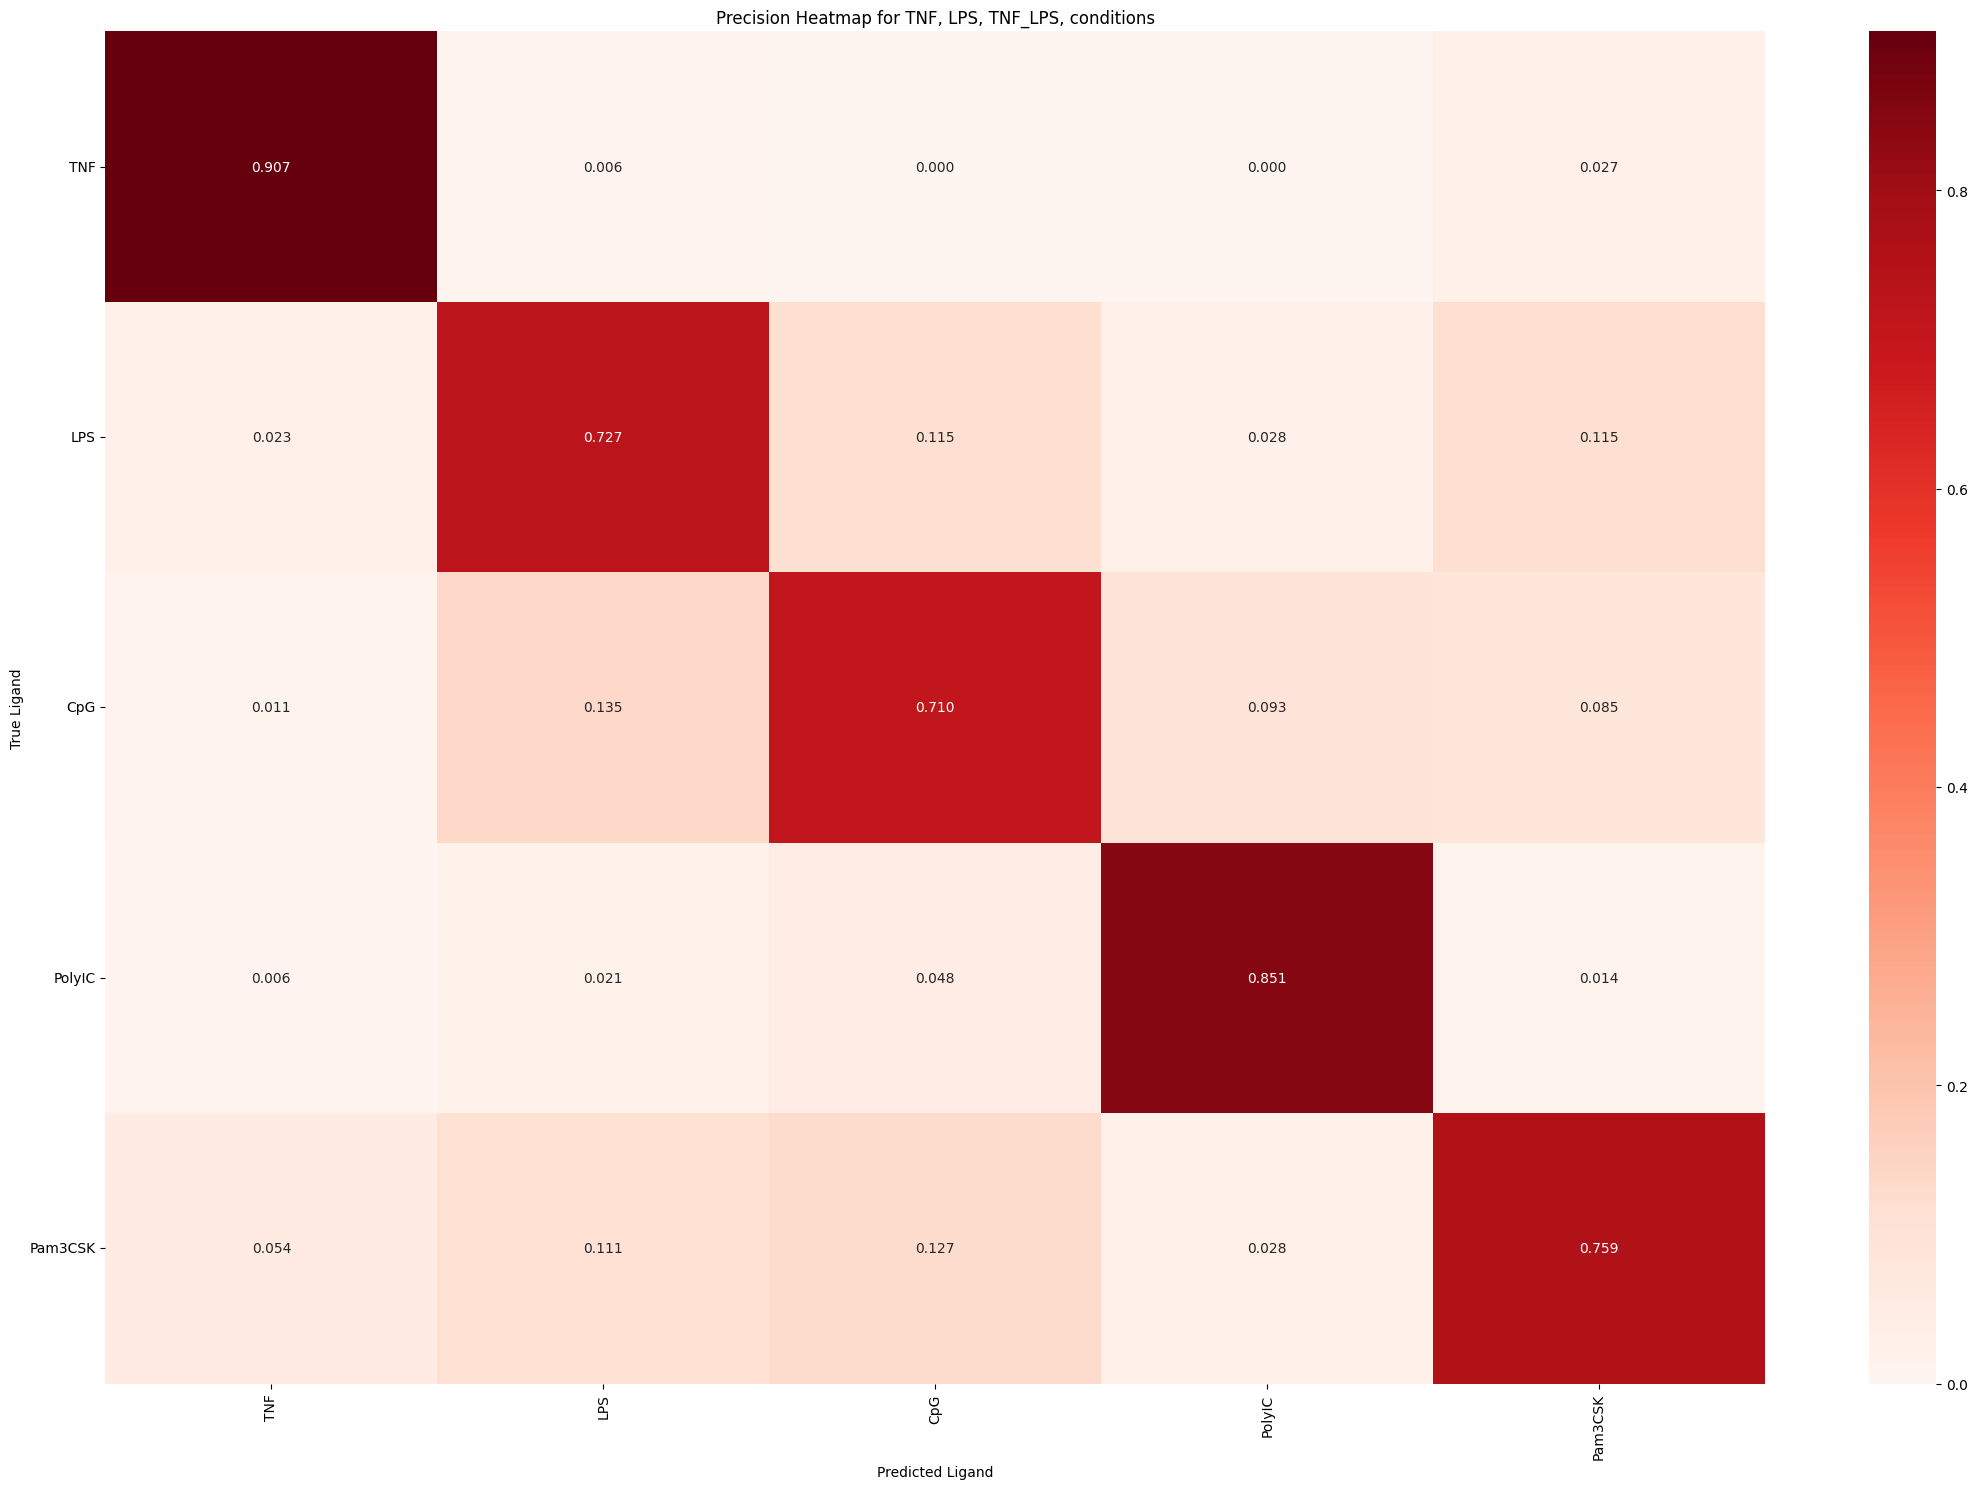

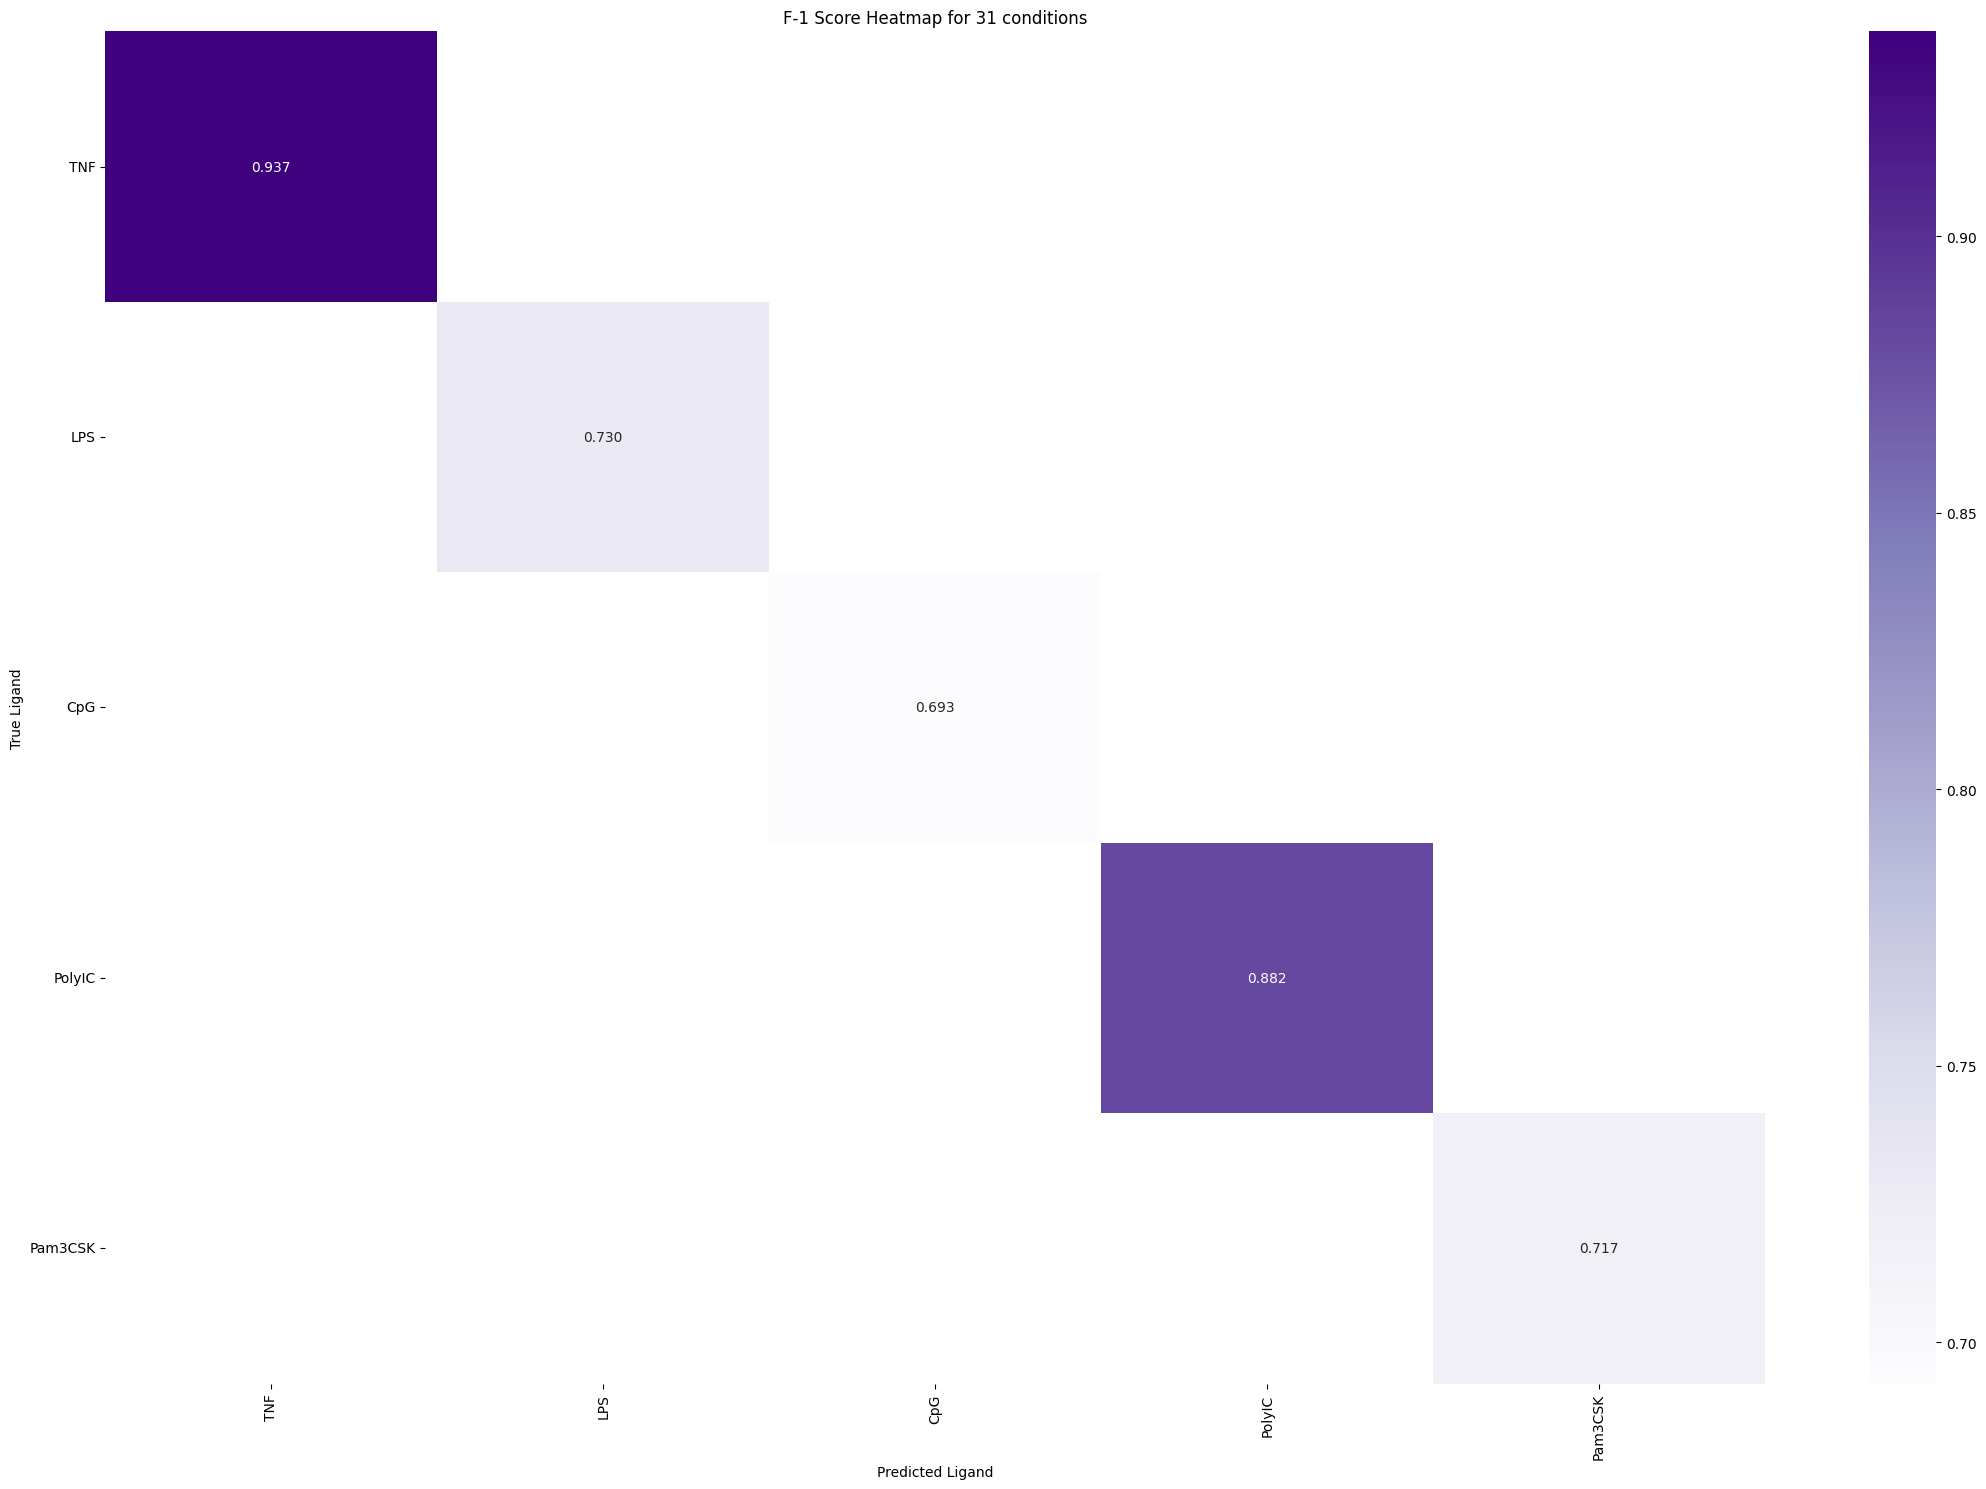

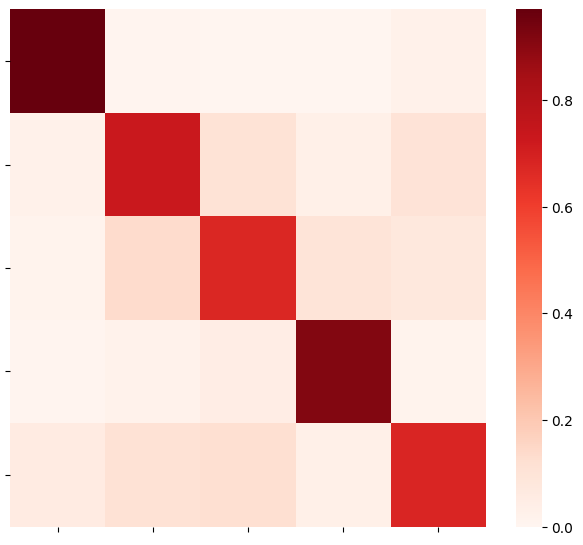

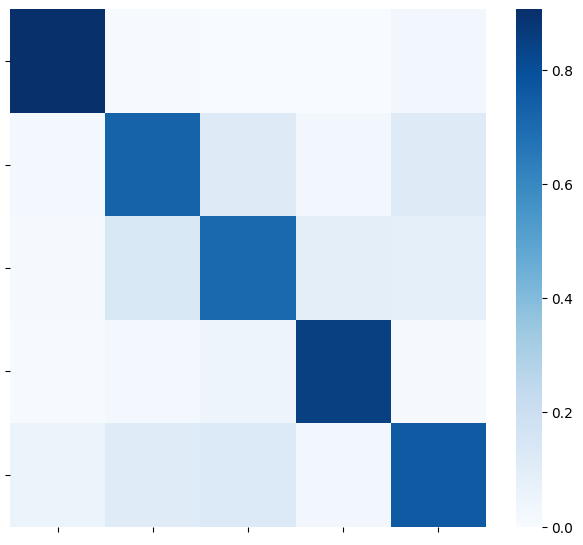

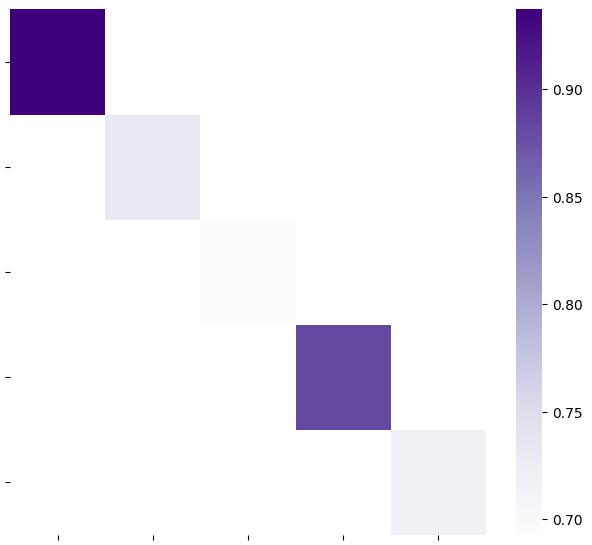

In [9]:
# Plot sensitivity heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(recall, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[label_mapping[i] for i in range(5)],
            yticklabels=[label_mapping[i] for i in range(5)])
plt.title('Sensitivity Heatmap for TNF, LPS, TNF_LPS, conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_sensitivity_heatmap", download=True, formats=['pdf'])
plt.show()

# Plot precision heatmap
plt.figure(figsize=(22, 15))
sns.heatmap(precision, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=[label_mapping[i] for i in range(5)],
            yticklabels=[label_mapping[i] for i in range(5)])
plt.title('Precision Heatmap for TNF, LPS, TNF_LPS, conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_precision_heatmap", download=True, formats=['pdf'])
plt.show()

# Plot F-1 DIAG score heatmap
plt.figure(figsize=(22,15))
sns.heatmap(f1_score_diagonal, annot=True, fmt='.3f', cmap='Purples',
            xticklabels=[label_mapping[i] for i in range(5)],
            yticklabels=[label_mapping[i] for i in range(5)])
plt.title('F-1 Score Heatmap for 31 conditions')
plt.xlabel('Predicted Ligand')
plt.ylabel('True Ligand')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
#save_and_download("31conditions_f1_score_heatmap", download=True, formats=['pdf'])
plt.show()

# Unlabeled sensitivity heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(recall, annot=False, cmap='Reds', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("5conditions_sensitivity_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()

# Unlabeled precision heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(precision, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("5conditions_precision_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()

# Unlabeled z-1 DIAG score heatmap
plt.figure(figsize=(450/72, 400/72))
sns.heatmap(f1_score_diagonal, annot=False, cmap='Purples', xticklabels=False, yticklabels=False)
plt.xticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping], rotation=90)
plt.yticks(ticks=np.arange(len(label_mapping)) + 0.5, labels=["" for _ in label_mapping])
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()
save_and_download("5conditions_f1_score_heatmap_unlabeled", download=True, formats=['pdf'])
plt.show()

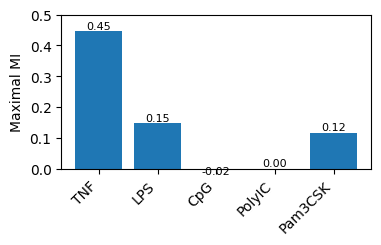

In [21]:
MI_vec = np.array([0.4461, 0.14851, -0.024234,3.0322e-15, 0.11725 ])
plt.figure(figsize=(4, 2))
num_classes = len(MI_vec)
colors = "tab:blue" # sns.color_palette("Blues_r", n_colors=num_classes)

bars = plt.bar(range(num_classes), MI_vec, color=colors)

#plt.title("True Positive Predictions for 31 Ligand Combinations using Sensitivity")
# plt.xlabel("Predicted Ligand")
plt.ylabel("Maximal MI")
plt.ylim(0, 0.5)
plt.xticks(range(num_classes), [label_mapping[i] for i in range(num_classes)], rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontsize=8)